# 09 – Pivot Analysis

Ce notebook charge les artefacts `probabilities` générés par un run MLflow (cf. `08_modeling_point_total.ipynb`) et visualise la calibration des probabilités over/under pour chaque pivot. Ajuste les chemins ci-dessous pour pointer vers le run/ modèle que tu veux analyser.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from src.mlflow_utils import get_latest_run_dir

RUN_DIR = get_latest_run_dir(target="POINT_TOTAL", experiment_name="point_total_regression")


MODEL_KEY = "ngboost"  # 'lgbm', 'xgb', 'ngboost', 'stacking'

summary_path = RUN_DIR / "artifacts" / "probabilities" / MODEL_KEY / f"{MODEL_KEY}_pivot_summary.csv"
samples_path = RUN_DIR / "artifacts" / "probabilities" / MODEL_KEY / "samples" / f"{MODEL_KEY}_pivot_samples.csv"

summary_df = pd.read_csv(summary_path)
samples_df = pd.read_csv(samples_path)
samples_df["actual_over"] = (samples_df["actual"] > samples_df["pivot"]).astype(int)
samples_df["pred_over"] = samples_df["prob_over"]

display(summary_df.head())
display(samples_df.head())

,pivot,prob_under,prob_over
0,218.5,0.746948,0.253052
1,219.5,0.761820,0.238180
2,220.5,0.776200,0.223800
3,221.5,0.790077,0.209923
4,222.5,0.803438,0.196562


,prediction,actual,sigma,pivot,prob_under,prob_over,actual_over,pred_over
0,213.815642,176,18.450298,229.5,0.802362,0.197638,0,0.197638
1,194.407797,189,17.377041,218.5,0.917194,0.082806,0,0.082806
2,214.275760,162,18.170634,225.5,0.731618,0.268382,0,0.268382
3,206.094393,185,18.922196,229.5,0.891945,0.108055,0,0.108055
4,191.201676,200,16.740390,244.5,0.999273,0.000727,0,0.000727


## Calibration par pivot

,pivot,actual_over_rate,predicted_over,count
0,218.5,0.258065,0.238723,31
1,219.5,0.282609,0.223649,46
2,220.5,0.232558,0.219026,43
3,221.5,0.294118,0.230382,34
4,222.5,0.157895,0.220560,38
5,223.5,0.325000,0.137654,40
6,224.5,0.277778,0.204936,36
7,225.5,0.344828,0.145674,29
8,226.5,0.148148,0.121078,27
9,227.5,0.032258,0.114124,31


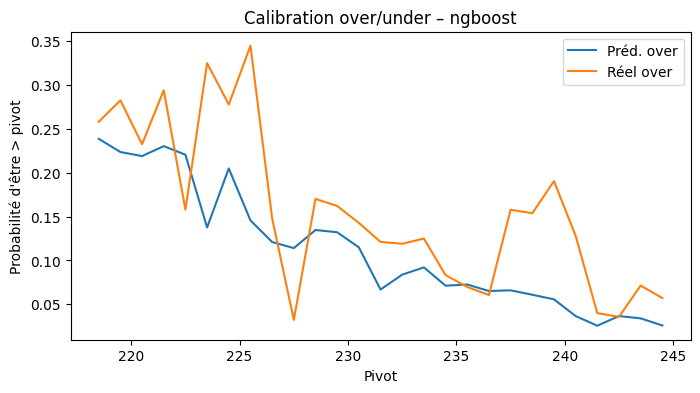

In [3]:
pivot_stats = (
    samples_df.groupby("pivot")
    .agg(
        actual_over_rate=("actual_over", "mean"),
        predicted_over=("pred_over", "mean"),
        count=("actual_over", "size"),
    )
    .reset_index()
)

display(pivot_stats)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pivot_stats["pivot"], pivot_stats["predicted_over"], label="Préd. over")
ax.plot(pivot_stats["pivot"], pivot_stats["actual_over_rate"], label="Réel over")
ax.set_xlabel("Pivot")
ax.set_ylabel("Probabilité d'être > pivot")
ax.legend()
ax.set_title(f"Calibration over/under – {MODEL_KEY}")
plt.show()

## Classement des pivots les plus "sûrs"

On calcule ci-dessous un score simple : distance entre la probabilité de dépassement et 0.5 (plus la probabilité est éloignée de 50 %, plus le modèle est confiant), pondéré par la différence entre la prédiction et la réalité.

In [4]:
samples_df["confidence"] = (samples_df["prob_over"] - 0.5).abs()
samples_df["hit"] = (samples_df["prob_over"] > 0.5) == (samples_df["actual"] > samples_df["pivot"])

top_edges = (
    samples_df.sort_values("confidence", ascending=False)
    [["prediction", "actual", "pivot", "prob_over", "prob_under", "confidence", "hit"]]
    .head(20)
)
display(top_edges)

,prediction,actual,pivot,prob_over,prob_under,confidence,hit
693,186.956963,191,240.5,0.000027,0.999973,0.499973,True
731,189.943995,218,243.5,0.000045,0.999955,0.499955,True
793,190.120563,180,236.5,0.000048,0.999952,0.499952,True
755,190.281648,183,237.5,0.000059,0.999941,0.499941,True
268,188.092818,196,235.5,0.000114,0.999886,0.499886,True
647,187.918313,183,242.5,0.000118,0.999882,0.499882,True
758,188.941406,203,239.5,0.000119,0.999881,0.499881,True
769,195.262071,208,241.5,0.000137,0.999863,0.499863,True
195,193.263239,197,237.5,0.000144,0.999856,0.499856,True
644,185.893404,155,237.5,0.000152,0.999848,0.499848,True


## Pivot bins (2 pts)

/tmp/ipykernel_1239555/2097160386.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samples_df.groupby('pivot_bin')


,pivot_bin,count,actual_over_rate,predicted_over
0,"[218.5, 220.5)",77,0.272727,0.229718
1,"[220.5, 222.5)",77,0.259740,0.224041
2,"[222.5, 224.5)",78,0.243590,0.178044
3,"[224.5, 226.5)",65,0.307692,0.178496
4,"[226.5, 228.5)",58,0.086207,0.117361
5,"[228.5, 230.5)",84,0.166667,0.133629
6,"[230.5, 232.5)",75,0.133333,0.093803
7,"[232.5, 234.5)",74,0.121622,0.087440
8,"[234.5, 236.5)",91,0.076923,0.071905
9,"[236.5, 238.5)",71,0.112676,0.065626


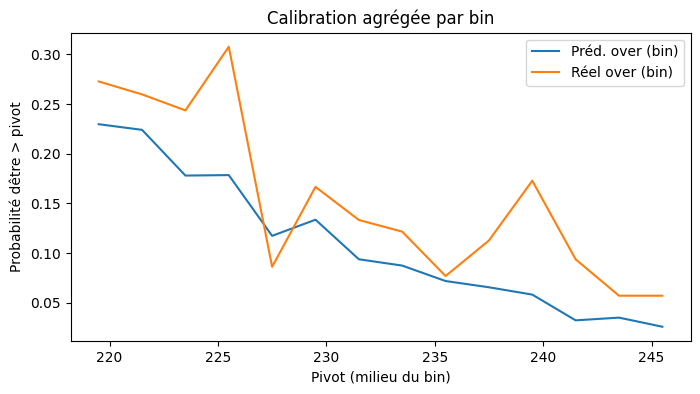

In [12]:
bin_edges = pd.interval_range(start=218.5, end=246.5, freq=2, closed='left')
samples_df['pivot_bin'] = pd.cut(samples_df['pivot'], bins=bin_edges)
bin_stats = (
    samples_df.groupby('pivot_bin')
    .agg(count=('actual_over','size'), actual_over_rate=('actual_over','mean'), predicted_over=('prob_over','mean'))
    .reset_index()
)
display(bin_stats)
if not bin_stats.empty:
    fig, ax = plt.subplots(figsize=(8,4))
    mids = bin_stats['pivot_bin'].apply(lambda x: x.mid if pd.notna(x) else pd.NA)
    ax.plot(mids, bin_stats['predicted_over'], label='Préd. over (bin)')
    ax.plot(mids, bin_stats['actual_over_rate'], label='Réel over (bin)')
    ax.set_xlabel('Pivot (milieu du bin)')
    ax.set_ylabel('Probabilité dêtre > pivot')
    ax.legend()
    ax.set_title('Calibration agrégée par bin')
    plt.show()


## Confiance vs taux de réussite

In [6]:
confidence_thresholds = [0.05, 0.1, 0.15, 0.2, 0.25]
records = []
for thresh in confidence_thresholds:
    subset = samples_df[samples_df['confidence'] >= thresh]
    hit_rate = subset['hit'].mean() if not subset.empty else float('nan')
    records.append({'threshold': thresh, 'count': len(subset), 'hit_rate': hit_rate})
confidence_df = pd.DataFrame(records)
display(confidence_df)


,threshold,count,hit_rate
0,0.05,985,0.846701
1,0.10,966,0.854037
2,0.15,924,0.860390
3,0.20,888,0.871622
4,0.25,840,0.882143


## Distribution des sigma

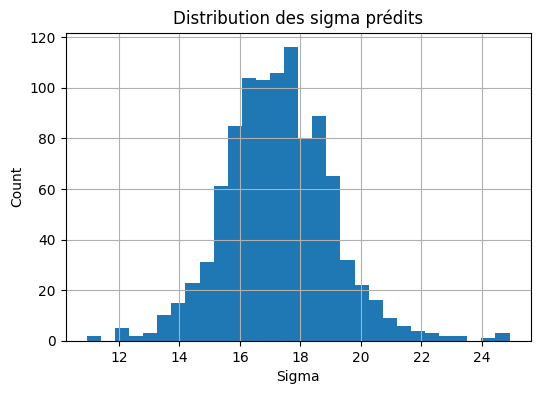

In [7]:
if 'sigma' in samples_df.columns:
    fig, ax = plt.subplots(figsize=(6,4))
    samples_df['sigma'].hist(bins=30, ax=ax)
    ax.set_title('Distribution des sigma prédits')
    ax.set_xlabel('Sigma')
    ax.set_ylabel('Count')
    plt.show()
else:
    print('Colonne sigma absente du fichier samples.')
